##  07. LightGBM

LightGBM은 XGBoost와 함께 부스팅 계열 알고리즘에서 가장 각광 받고 있다. 
XGBoost 단점 
- 학습 시간이 오래걸림
- 많은 파라미터를 튜닝하기에 어려움이 있다. <br>

LightGBM 장점 
- 학습시간이 적다
- 메모리 사용량도 적다
- 기존 분할 방법과는 다르게 리트 중심 트리 분할 방식을 사용한다. 

In [3]:
import lightgbm
from lightgbm import LGBMClassifier

#### LightGBM 하이퍼 파라미터 
리프 노드가 계속 분할되면서 트리의 깊이가 깊어지므로 이러한 트리 특성에 맞는 하이퍼 파라미터가 필요하다 <br>
주요 파라미터
- num_iterations [default = 100] : 반복 수행하려는 트리의 개수를 지정. 크게 지정할수록 예특 성능이 높아질수는 있으나, 너무 크게 지정하면 오히려 과적합으로 성능이 저하될 수 있다.
- learning_rate [default = 100] : 0에서 1 사이 값을 지정하며 부스팅 스텝을 반복적으로 수행할 때 업데이트되는 학습률 값이다.
- max_depth [default = -1] : 트리 기반 알고리즘과 동일 
- min_data_in_leaf [default = 20] : 결정 트리의 min_samples_leaf와 같은 파라미터
- num_leaves [default = 31] : 하나의 트리가 가질 수 있는 최대 리프 개수
- boosting [default = gbdt] : 부스팅의 트리를 생성하는 알고리즘을 기술
    - gbdt : 일반적인 그래디언트 부스팅 결정 트리
    - rl : 랜덤 포레스트 
- bagging_fraction [default = 1.0] : 트리가 커져서 과적합되는 것을 제어하기 위해서 데이터를 샘플링하는 비율을 지정 
- feature_fraction [default = 1.0] : 개별 트리를 학습할 때마다 무작위로 선택하는 피처의 비율
- lambda_l2 [default = 0.0] : L2 regulation 제어를 위한 값. 피처 개수가 많을 경우 적용을 검토하여 값이 클수록 과적합 감소 효과가 있다.
- lambda_l1 [default = 0.0 ] : L1 regulation 제어를 위한 값이다. 
<br>
Learning Task 파라미터 

- objective : 최솟값을 가져야 할 손실함수를 정의 

#### 하이퍼 파라미터 튜닝 방안 
- num_leaves : 개별 트리가 가질 수 있는 최대 리프의 개수이며 모델의 복잡도를 제어하는 주요 파라미터다. 개수를 높이면 정확도가 높아지지만, 과적합 영향도 커진다
- min_data_in_leaf : 사이킷런 래퍼 클래스에서 min_child_sampes로 이름이 바뀐다. 과적합을 개선하기 위한 중요한 파라미터다
- max_depth : 명시적으로 깊이를 제한한다. 과적합 개선 가능 

#### LightGBM 적용 - 위스콘신 유방암 예특 

In [12]:
# LightGBM의 파이썬 패키지인 lightgbm에서 LGBMClassifier 임포트
from lightgbm import LGBMClassifier
from lightgbm import early_stopping, log_evaluation

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target']=dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

# 앞서 XGBoost와 동일하게 n_estimators는 400 설정.
lgbm_wrapper = LGBMClassifier(n_estimators=400, learning_rate=0.05)

# LightGBM도 XGBoost와 동일하게 조기 중단 수행 가능
evals=[(X_tr, y_tr),(X_val, y_val)]
lgbm_wrapper.fit(X_tr, y_tr, callbacks=[early_stopping(stopping_rounds=50), log_evaluation(period=10)],
                 eval_metric="logloss", eval_set=evals)
preds=lgbm_wrapper.predict(X_test)
pred_proba=lgbm_wrapper.predict_proba(X_test)[:,1]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 251, number of negative: 158
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4092
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.613692 -> initscore=0.462858
[LightGBM] [Info] Start training from score 0.462858
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

def get_clf_eval(y_test, pred, pred_proba):
  confusion=confusion_matrix(y_test, pred)
  accuracy=accuracy_score(y_test, pred)
  precision=precision_score(y_test, pred)
  recall=recall_score(y_test, pred)
  f1=f1_score(y_test, pred)

  #ROC-AUC 추가
  roc_auc=roc_auc_score(y_test, pred_proba)
  print('오차행렬')
  print(confusion)

  #ROC-AUC print 추가
  print('정확도:{0:.4f}, 정밀도:{1:.4f}, 재현율{2:.4f}, F1:{3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall,f1,roc_auc))
     

In [16]:
get_clf_eval(y_test, preds,pred_proba)

오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561, 정밀도:0.9615, 재현율0.9740, F1:0.9677, AUC:0.9877


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

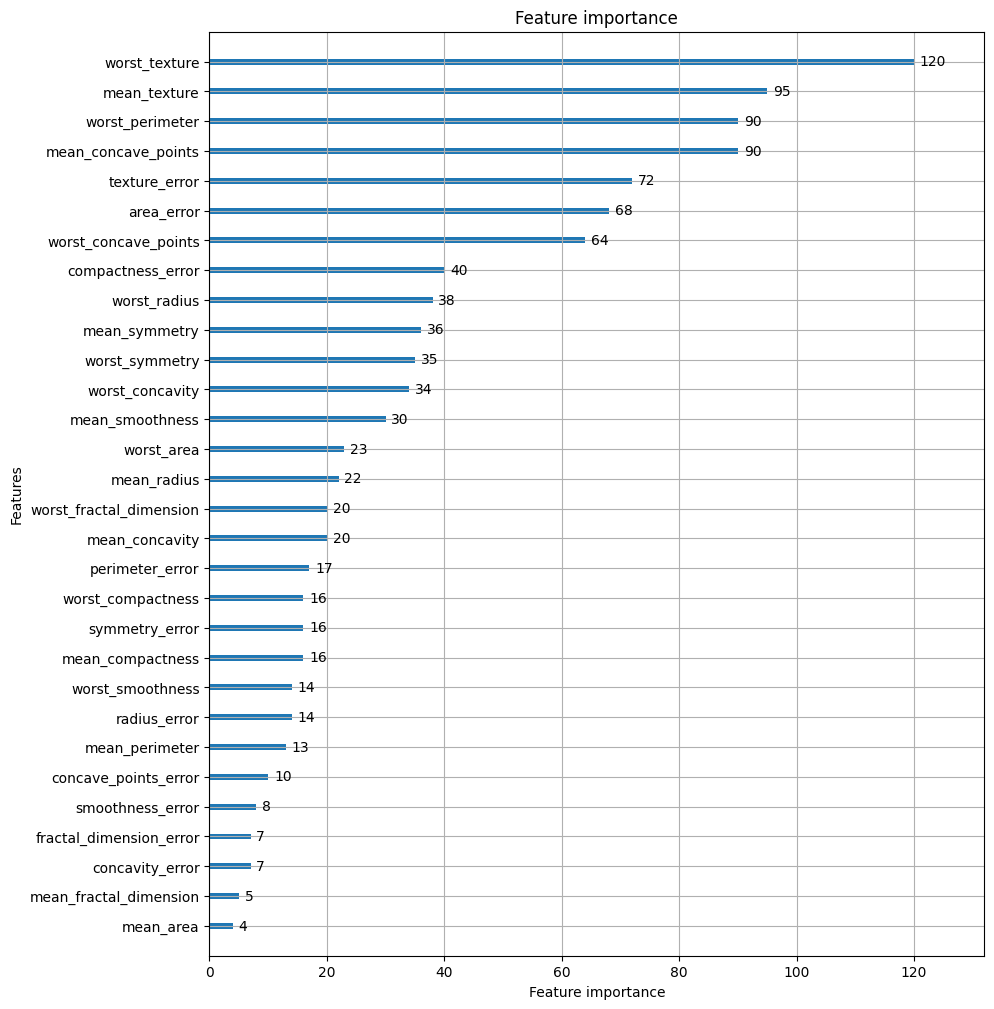

In [17]:
# plot_importance()를 이용하여 feature 중요도 시각화
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12))
plot_importance(lgbm_wrapper, ax=ax)

## 08. 베이지안 최적화 기반의 HyperOpt를 이용한 하이퍼 파라미터 튜닝
Grid Search 방식의 단점 : 튜닝해야 할 하이퍼 파라미터 개수가 많을 경우 최적화 수행 시간이 오래 걸린다. 

In [19]:

params = {
    'max_depth':[10,20,30,40,50], 'num_leaves':[35,45,55,65],
    'colsample_bytree':[0.5,0.6,0.7,0.8,0.9], 'subsample':[0.5,0.6,0.7,0.8,0.9],
    'min_child_weight':[10,20,30,40], 'reg_alpha':[0.01,0.05,0.1]
}

#### 베이지안 최적화 개요
베이지안 최적화는 목적 함수 식을 제대로 알 수 없는 블랙 박스 형태의 함수에서 최대 또는 최소 함수 반환 값을 만드는 최적 입력값을 가능한 적은 시도를 통해 빠르고 효과적으로 찾아주는 방식이다. <br>
- 1단계 : 최초에는 랜덤하게 하이퍼 파라미터들을 샘플링하고 성능 결과를 관측한다.
- 2단계 : 관측된 값을 기반으로 대체 모델은 최적 함수를 추정한다. 
- 3단계 : 추정된 최적 함수를 기반으로 획득 함수(Acquisition Function)는 다음으로 관측할 하이퍼 파라미터 값을 계산한다.
- 4단계 : 획특 함수로부터 전달된 하이퍼 파라미터를 수행하여 관측된 값을 기반으로 대체 모델은 갱신되어 다시 최적 함수를 예측 추정한다. 

#### HyperOpt 사용하기
베이지안 최적화를 머신러닝 모델의 하이터 파라미터 튜닝에 적용할 수 있게 제공되는 여러 파이썬 패키지들이 있다. 

In [4]:
# pip install hypteropt 
import sys
!{sys.executable} -m pip install "setuptools<81" --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.9 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1


사용 로직 : 입력변수명과 입력값의 검색 공간 설정 --> 목적 함수의 설정 --> 마지막으로 목적 함수의 반환 최솟값을 가지는 최적 입력값을 유추하는 것

In [5]:
from hyperopt import hp

#-10~10까지 1간격을 가지는 입력변수 x와 -15~15까지 1간격으로 입력변수 y설정
search_space = {'x': hp.quniform('x', -10, 10, 1), 'y': hp.quniform('y', -15, 15, 1) }


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


- hp.quniform(label,low,high,q) : label로 지정된 입력값 변수 검색 공각을 최솟값에서 최댓값까지 q의 간격을 가지고 설정 
- hp.uniform(label,low,high) : 최솟값에서 최댓값까지 정규 분포 형태의 검색 공간 설정
- hp.randint(label, low, high) : exp(uniform(low,high)) 값을 반환하며, 반환 값의 로그 변환 된 값은 정규 분포 형태를 가지는 검색 공간 설정
- hp.choice(label, options). : 검색값이 문자열 또는 문자열과 숫자값이 섞여 있을 경유 설정 


In [6]:
from hyperopt import STATUS_OK

#목적 함수를 생성. 변숫값과 변수 겁색 공간을 가지는 딕셔너리를 인자로 받고, 특정값을 반환
def objective_func(search_space):
    x = search_space['x']
    y = search_space['y']
    retval = x**2 - 20*y

    return retval

- fb : 위에서 생성한 objective_func 같은 목적 함수
- space： 위에서 생성한 search_space와 같은 검색 공간 딕셔너리
- algo： 베이지안 최적화 적용 알고리즘 
- max_evals： 최적 입력값을 찾기 위한 입력값 시도 횟수
- trials： 최적 입력값을 찾기 위해 시도한 입력값 및 해당 입력값의 목적 함수 반환값 결과를 저장하는 데 사용
- rstate： fmin()을 수행할 때마다 동일한 결괏값을 가질 수 있도록 설정하는 랜덤 시드(seed) 값

In [7]:
import numpy as np
from hyperopt import fmin, tpe, Trials

# 입력 결괏값을 저장한 Trials 객체값 생성.
trial_val = Trials()
#목적함수의 최솟값을 반환하는 최적 입력 변숫값을 5번의 입력값 시도로 찾아냄
best_01 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=5,
               trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best_01:', best_01)

100%|██████████| 5/5 [00:00<00:00, 1566.44trial/s, best loss: -224.0]
best_01: {'x': np.float64(-4.0), 'y': np.float64(12.0)}


In [8]:
trial_val = Trials()
best_02 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=5,
               trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best_02:', best_02)

100%|██████████| 5/5 [00:00<00:00, 1148.68trial/s, best loss: -224.0]
best_02: {'x': np.float64(-4.0), 'y': np.float64(12.0)}


In [9]:
#fmin()안에 들어가는 trials객체의 속송에 파이썬 리스트로 목적 함수 반환값들이 저장됨
#리스트 내부의 원소는 loss, status 와 같은 딕셔너리임
print(trial_val.results)

[{'loss': -64.0, 'status': 'ok'}, {'loss': -184.0, 'status': 'ok'}, {'loss': 56.0, 'status': 'ok'}, {'loss': -224.0, 'status': 'ok'}, {'loss': 61.0, 'status': 'ok'}]


In [10]:
#Trails객체의vals속성에 입력변수명 형태로 저장됨
# print(trial_val.vals) # Original failing line

# Fix: Extract x and y values from trial_val.trials manually
x_vals = [t['misc']['vals']['x'][0] for t in trial_val.trials]
y_vals = [t['misc']['vals']['y'][0] for t in trial_val.trials]

print({'x': x_vals, 'y': y_vals})

{'x': [np.float64(-6.0), np.float64(-4.0), np.float64(4.0), np.float64(-4.0), np.float64(9.0)], 'y': [np.float64(5.0), np.float64(10.0), np.float64(-2.0), np.float64(12.0), np.float64(1.0)]}


In [11]:
import pandas as pd

# Extract x and y values from trial_val.trials manually
x_values_from_trials = [t['misc']['vals']['x'][0] for t in trial_val.trials]
y_values_from_trials = [t['misc']['vals']['y'][0] for t in trial_val.trials]

#results에서 loss키값에 해당하는 밸류들을 추출하여 list로 생성
losses = [loss_dict['loss'] for loss_dict in trial_val.results]
#데이터 프레임으로 생성
# Use the manually extracted lists instead of trial_val.vals
result_df = pd.DataFrame({'x': x_values_from_trials, 'y': y_values_from_trials,'losses':losses})
result_df

,x,y,losses
0,-6.0,5.0,-64.0
1,-4.0,10.0,-184.0
2,4.0,-2.0,56.0
3,-4.0,12.0,-224.0
4,9.0,1.0,61.0


#### HyperOpt를 이용한 XGBoost 하이퍼 파라미터 최적화
적용해야 할 하이퍼 ㅍ하라미터와 검색 공간을 설정, 목적함수에서 XGBoost를 학습 후에 예측 성능 결과를 반환 값으로 설정한다. 그리고 fmin() 함수에서 목적 함수를 하이퍼 파라미터 겸 색 공간의 입력값들을 사용하여 최적의 예측 성능 결과를 반환하는 최적 입력값들을 결정하는 것이다. 

In [16]:
from lightgbm import LGBMClassifier
from lightgbm import early_stopping, log_evaluation

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target']=dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

#전체 데이터 중 80%는 학습용 데이터, 나머지는 데스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156 )

#앞에서 추출한 학습 데이터를 다시 학습과 검증 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156 )

In [17]:
from hyperopt import hp

# max_depth는 5에서 20까지 1간격으로, min_child_weight는 1에서 2까지 1간격으로
#colsample_bytree는 0.5에서 1사이, learning_rate는 0.01에서 0.2 사이 정규 분포된 값으로 검색
xgb_search_params = {'max_depth': hp.quniform('max_depth', 5, 20, 1),
                     'min_child_weight': hp.quniform('min_child_weight', 1,2,1),
                     'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
                     'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1)
                    }

In [18]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

#fmin()에서 입력된 search_space값으로 입력된 모든 값은 실수형임
#XGBClassifier의 정수형 하이퍼 파라미터는 정수형 변환을 해줘야함
#정확도는 높을 수록 더 좋은 수치임. -1*정확도를 곱해서 큰 정확도 값일 수록 최소가 되도록 변환
def objective_func(search_space):
    #수행 시간 절약을 위해 nestimators는 100으로 축소
    xgb_clf = XGBClassifier(n_estimators=100, max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            learning_rate=search_space['learning_rate'],
                            colsample_bytree=search_space['colsample_bytree'],
                            eval_metric='logloss', random_state=156, n_jobs=1)
    accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring='accuracy', cv=3)

    # accuracy는 cv=3 개수만큼의 정확도 결과를 가지므로 이를 평균해서 반환하되 -1을 곱해줌
    return {'loss':-1 * np.mean(accuracy), 'status': STATUS_OK}

In [19]:
import numpy as np
from hyperopt import fmin, tpe, Trials

trial_val = Trials()
best = fmin(fn=objective_func,
            space=xgb_search_params,
            algo=tpe.suggest,
            max_evals=20,
            trials=trial_val, rstate=np.random.default_rng(seed=9))
print('best:',best)

100%|██████████| 20/20 [00:01<00:00, 16.39trial/s, best loss: -0.967047170907401]
best: {'colsample_bytree': np.float64(0.548301545497125), 'learning_rate': np.float64(0.1840281762576621), 'max_depth': np.float64(18.0), 'min_child_weight': np.float64(2.0)}


In [22]:
print('colsample_bytree:{0}, learning_rate:{1},max_depth:{2}, min_child_weight:{3}'.format(
    round(best['colsample_bytree'], 5), round(best['learning_rate'], 5),
    int(best['max_depth']), int(best['min_child_weight'])
))

colsample_bytree:0.5483, learning_rate:0.18403,max_depth:18, min_child_weight:2


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

def get_clf_eval(y_test, pred, pred_proba):
  confusion=confusion_matrix(y_test, pred)
  accuracy=accuracy_score(y_test, pred)
  precision=precision_score(y_test, pred)
  recall=recall_score(y_test, pred)
  f1=f1_score(y_test, pred)

  #ROC-AUC 추가
  roc_auc=roc_auc_score(y_test, pred_proba)
  print('오차행렬')
  print(confusion)

  #ROC-AUC print 추가
  print('정확도:{0:.4f}, 정밀도:{1:.4f}, 재현율{2:.4f}, F1:{3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall,f1,roc_auc))
     

In [25]:
xgb_wrapper = XGBClassifier(n_estimators=400,
                          learning_rate=round(best['learning_rate'], 5),
                          max_depth=int(best['max_depth']),
                          min_child_weight=int(best['min_child_weight']),
                          colsample_bytree=round(best['colsample_bytree'], 5)
                          )
evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, eval_set=evals, verbose=True)

preds = xgb_wrapper.predict(X_test)
pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1 ]

get_clf_eval(y_test, preds, pred_proba)

[0]	validation_0-logloss:0.52449	validation_1-logloss:0.55884


[1]	validation_0-logloss:0.42507	validation_1-logloss:0.48228
[2]	validation_0-logloss:0.35239	validation_1-logloss:0.43464
[3]	validation_0-logloss:0.29534	validation_1-logloss:0.39473
[4]	validation_0-logloss:0.25113	validation_1-logloss:0.36472
[5]	validation_0-logloss:0.21710	validation_1-logloss:0.34720
[6]	validation_0-logloss:0.18847	validation_1-logloss:0.33087
[7]	validation_0-logloss:0.16340	validation_1-logloss:0.31198
[8]	validation_0-logloss:0.14475	validation_1-logloss:0.29894
[9]	validation_0-logloss:0.12874	validation_1-logloss:0.28308
[10]	validation_0-logloss:0.11528	validation_1-logloss:0.28369
[11]	validation_0-logloss:0.10440	validation_1-logloss:0.27770
[12]	validation_0-logloss:0.09313	validation_1-logloss:0.27178
[13]	validation_0-logloss:0.08539	validation_1-logloss:0.26812
[14]	validation_0-logloss:0.07803	validation_1-logloss:0.26425
[15]	validation_0-logloss:0.07247	validation_1-logloss:0.26516
[16]	validation_0-logloss:0.06670	validation_1-logloss:0.26534
[

## 스태킹 앙상블
스태킹(Stacking)은 개별적인 여러 알고리즘을 서로 결합해 예측 결과를 도출한다는 점에서 이전 배깅과 부스팅과 비슷하지만, 개별 알고리즘으로 예측한 데이터를 기반으로 다시 예측을 수행한다. <br>
여러 개의 모델에 대한 예특값을 합한 후, 이에 대한 예측을 다시 수행
두 종류 모델 필요
- 개별적 기반 모델
- 개별 기반 모델의 예측 데이

#### 기본 스태킹 모델

In [27]:
 import numpy as np
 from sklearn.neighbors import KNeighborsClassifier
 from sklearn.ensemble import RandomForestClassifier
 from sklearn.ensemble import AdaBoostClassifier
 from sklearn.tree import DecisionTreeClassifier
 from sklearn.linear_model import LogisticRegression

 from sklearn.datasets import load_breast_cancer
 from sklearn.model_selection import train_test_split
 from sklearn.metrics import accuracy_score

 cancer_data = load_breast_cancer()

 X_data = cancer_data.data
 y_label = cancer_data.target

 X_train , X_test , y_train , y_test = train_test_split(X_data , y_label , test_size=0.2 , random_state=0)

In [28]:
#개별 ML 모델 생성
knn_clf  = KNeighborsClassifier(n_neighbors=4)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0)
dt_clf = DecisionTreeClassifier()
ada_clf = AdaBoostClassifier(n_estimators=100)

#스태킹으로 만들어진 데이터 세트를 학습, 예측할 최종 모델
lr_final = LogisticRegression()

In [ ]:
#개별 모델들을 학습
knn_clf.fit(X_train, y_train)
rf_clf.fit(X_train , y_train)
dt_clf.fit(X_train , y_train)
ada_clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [30]:
#학습된 개별 모델들이 각자 반환하는 예측 데이터 세트를 생성하고 개별 모델의 정확도 측정
knn_pred = knn_clf.predict(X_test)
rf_pred = rf_clf.predict(X_test)
dt_pred = dt_clf.predict(X_test)
ada_pred = ada_clf.predict(X_test)

print('KNN 정확도: {0:.4f}'.format(accuracy_score(y_test, knn_pred)))
print('랜덤 포레스트 정확도: {0:4f}'.format(accuracy_score(y_test, rf_pred)))
print('결정 트리 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))
print('에이다부스트 정확도: {0:.4f} :'.format(accuracy_score(y_test, ada_pred)))

KNN 정확도: 0.9211
랜덤 포레스트 정확도: 0.964912
결정 트리 정확도: 0.9035
에이다부스트 정확도: 0.9737 :


In [31]:
pred = np.array(([knn_pred, rf_pred, dt_pred, ada_pred]))
print(pred.shape)

#transpose를 이용해 행과 열의 위치 교환. 칼럼 레벨로 각 알고리즘의 예측 결과를 피처로 만듦
pred = np.transpose(pred)
print(pred.shape)

(4, 114)
(114, 4)


In [33]:
lr_final.fit(pred, y_test)
final = lr_final.predict(pred)

print('최종 메타 모델의 예측 정확도 :{0:.4f}'.format(accuracy_score(y_test, final)) )

최종 메타 모델의 예측 정확도 :0.9649


#### CV 세트 기반의 스태킹
CV 세트 기반의 스태킹 모델은 과적합을 개선하기 위해 최종 메타 모델을 위한 데이터 세트를 만들 때 교차 검증 기반으로 예측된 결과 데이터 세트를 이용한다. 
- 스텝 1 : 각 모델별로 원본 학습/테스트 데이터를 예측한 결과 값을 기반으로 메타 모델을 위한 학습용/테스트용 데이터를 생성한다
    - 학습용 데이터를 N개의 폴드로 나눈다 
- 스텝 2 : 스텝 1에서 개별 모델들이 생성한 학습용 데이터를 모두 스태킹 형태로 합쳐서 메타 모델이 학습할 최종 학습용 데이터 세트를 생성한다 pg302-303

In [34]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

#개별 기반 모델에서 최종 메타 모델이 사용할 학습 및 테스트용 데이터를 생성하기 위한 함수
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds ):
    #지정된 n_folds값으로 KFold 생성
    kf = KFold(n_splits=n_folds, shuffle=False)
    #추후에 메타 모델이 사용할 학습데이터 반환을 위한 넘파이 배열 초기화
    train_fold_pred = np.zeros((X_train_n.shape[0],1))
    test_pred = np.zeros((X_test_n.shape[0],n_folds))
    print(model.__class__.__name__,'model 시작')

    for folder_counter, (train_index, valid_index) in enumerate(kf.split(X_train_n)):
        #입력된 학습 데이터에서 기반 모델이 학습/예측할 폴드 데이터 세트 추출
        print('\t 폴드 세트: ', folder_counter, '시작')
        X_tr = X_train_n[train_index]
        y_tr = y_train_n[train_index]
        X_te = X_train_n[valid_index]

        #폴드 세트 내부에서 다시 만들어진 학습 데이터로 기반 모델의 학습 수행
        model.fit(X_tr, y_tr)
        #폴드 세트 내부에서 다시 만들어진 검증 데이터로 기반 모델 예측 후 데이터 저장
        train_fold_pred[valid_index,:] = model.predict(X_te).reshape(-1,1)
        #입력된 원본 테스트 데이터를 폴드 세드내 학습된 기반 모델에서 예측 후 데이터 저장
        test_pred[:,folder_counter] = model.predict(X_test_n)

    #폴드 세트 내에서 원본 테스트 데이터를 예측한 데이터를 평균하여 테스트 데이터로 생성
    test_pred_mean = np.mean(test_pred, axis=1).reshape(-1,1)

    #train_fold_pred 는 최종 메타 모델이 사용하는 학습데이터, test_pred_mean은 테스트 데이터
    return train_fold_pred, test_pred_mean

In [35]:
knn_train, knn_test = get_stacking_base_datasets(knn_clf, X_train, y_train, X_test, 7)
rf_train, rf_test = get_stacking_base_datasets(rf_clf, X_train, y_train, X_test, 7)
dt_train, dt_test = get_stacking_base_datasets(dt_clf, X_train, y_train, X_test,  7)
ada_train, ada_test = get_stacking_base_datasets(ada_clf, X_train, y_train, X_test, 7)

KNeighborsClassifier model 시작
	 폴드 세트:  0 시작
	 폴드 세트:  1 시작
	 폴드 세트:  2 시작
	 폴드 세트:  3 시작
	 폴드 세트:  4 시작
	 폴드 세트:  5 시작
	 폴드 세트:  6 시작
RandomForestClassifier model 시작
	 폴드 세트:  0 시작
	 폴드 세트:  1 시작
	 폴드 세트:  2 시작
	 폴드 세트:  3 시작
	 폴드 세트:  4 시작
	 폴드 세트:  5 시작
	 폴드 세트:  6 시작
DecisionTreeClassifier model 시작
	 폴드 세트:  0 시작
	 폴드 세트:  1 시작
	 폴드 세트:  2 시작
	 폴드 세트:  3 시작
	 폴드 세트:  4 시작
	 폴드 세트:  5 시작
	 폴드 세트:  6 시작
AdaBoostClassifier model 시작
	 폴드 세트:  0 시작
	 폴드 세트:  1 시작
	 폴드 세트:  2 시작
	 폴드 세트:  3 시작
	 폴드 세트:  4 시작
	 폴드 세트:  5 시작
	 폴드 세트:  6 시작


In [36]:
Stack_final_X_train = np.concatenate((knn_train, rf_train, dt_train, ada_train), axis=1)
Stack_final_X_test = np.concatenate((knn_test, rf_test, dt_test, ada_test), axis=1)
print('원본 학습 피처 데이터 Shape:',X_train.shape, '원본 테스트 피처 Shape:',X_test.shape)
print('스태킹 학습 피처 데이터 Shape:', Stack_final_X_train.shape,
      '스태킹 테스트 피처 데이터 Shape:',Stack_final_X_test.shape)

원본 학습 피처 데이터 Shape: (455, 30) 원본 테스트 피처 Shape: (114, 30)
스태킹 학습 피처 데이터 Shape: (455, 4) 스태킹 테스트 피처 데이터 Shape: (114, 4)


In [37]:
lr_final.fit(Stack_final_X_train, y_train)
stack_final = lr_final.predict(Stack_final_X_test)

print('최종 메타 모델의 예측 정확도: {0:.4f}'.format(accuracy_score(y_test, stack_final)))

최종 메타 모델의 예측 정확도: 0.9737
